In [1]:
import pandas as pd
print(pd.__version__)

3.0.3


In [3]:
import pandas as pd

df = pd.DataFrame({
    "hours_studied": [1, 2, 3, 4, 5],
    "passed": [0, 0, 0, 1, 1]
})
df

,hours_studied,passed
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1


In [6]:
import pandas as pd

students = pd.read_csv("data/studentInfo.csv")
vle = pd.read_csv("data/studentVle.csv")
assessments = pd.read_csv("data/studentAssessment.csv")
registration = pd.read_csv("data/studentRegistration.csv")
courses = pd.read_csv("data/courses.csv")

students.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [7]:
students["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [8]:
def label(x):
    if x == "Pass":
        return 0
    elif x == "Fail":
        return 1
    else:
        return 2

students["target"] = students["final_result"].apply(label)

students[["final_result", "target"]].head()

,final_result,target
0,Pass,0
1,Pass,0
2,Withdrawn,2
3,Pass,0
4,Pass,0


In [9]:
students["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [10]:
def risk_label(x):
    if x in ["Pass", "Distinction"]:
        return 0
    else:
        return 1

students["target"] = students["final_result"].apply(risk_label)

students["target"].value_counts()

target
1    17208
0    15385
Name: count, dtype: int64

In [12]:
students.groupby("id_student").size().sort_values(ascending=False).head()

id_student
584077     5
172965     4
600814     4
609605     4
2046628    4
dtype: int64

In [13]:
vle_features = vle.groupby("id_student").agg(
    total_clicks=("sum_click", "sum"),
    avg_clicks=("sum_click", "mean"),
    active_days=("date", "nunique")
).reset_index()

vle_features.head()

,id_student,total_clicks,avg_clicks,active_days
0,6516,2791,4.216012,159
1,8462,656,2.157895,56
2,11391,934,4.765306,40
3,23629,161,2.728814,16
4,23698,910,2.983607,70


In [14]:
df = students.merge(vle_features, on="id_student", how="left")
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target,total_clicks,avg_clicks,active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,934.0,4.765306,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,1435.0,3.337209,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,281.0,3.697368,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,2158.0,3.254902,123.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,1034.0,2.937500,70.0


In [16]:
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target,total_clicks,avg_clicks,active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,934.0,4.765306,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,1435.0,3.337209,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,281.0,3.697368,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,2158.0,3.254902,123.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,1034.0,2.937500,70.0


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
from sklearn.metrics import classification_report, accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8271207240374291
              precision    recall  f1-score   support

           0       0.79      0.85      0.82      3051
           1       0.86      0.80      0.83      3468

    accuracy                           0.83      6519
   macro avg       0.83      0.83      0.83      6519
weighted avg       0.83      0.83      0.83      6519



In [22]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

active_days                             0.263883
total_clicks                            0.215161
avg_clicks                              0.114170
id_student                              0.069829
studied_credits                         0.032181
code_module_BBB                         0.017752
highest_education_Lower Than A Level    0.014972
code_module_CCC                         0.014287
gender_M                                0.014209
code_module_FFF                         0.013939
num_of_prev_attempts                    0.013268
code_module_GGG                         0.012082
age_band_35-55                          0.011223
code_presentation_2014J                 0.009972
code_module_DDD                         0.009046
dtype: float64

In [24]:
model.fit(X_train.drop(columns=["id_student"], errors="ignore"), y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
X = df.drop(columns=[
    "target",
    "final_result",
    "id_student"
], errors="ignore")

y = df["target"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
import shap

c:\Users\braxt\OneDrive\Desktop\Student Risk Personal Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [2]:
import os

os.chdir(r"C:\Users\braxt\OneDrive\Desktop\Student Risk Personal Project")

print(os.getcwd())

C:\Users\braxt\OneDrive\Desktop\Student Risk Personal Project


In [3]:
import pandas as pd

students = pd.read_csv("data/studentInfo.csv")
vle = pd.read_csv("data/studentVle.csv")
assessments = pd.read_csv("data/studentAssessment.csv")
registration = pd.read_csv("data/studentRegistration.csv")
courses = pd.read_csv("data/courses.csv")

In [8]:
df.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'total_clicks',
       'avg_clicks', 'active_days'],
      dtype='str')

In [12]:
X = df.drop(columns=["target", "final_result", "id_student"], errors="ignore")
y = df["target"]

X = pd.get_dummies(X, drop_first=True)

In [13]:
df.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'target',
       'total_clicks', 'avg_clicks', 'active_days'],
      dtype='str')

In [14]:
df["target"] = df["final_result"].apply(
    lambda x: 1 if x in ["Withdrawn", "Fail"] else 0
)

In [15]:
df["target"].value_counts()

target
1    17208
0    15385
Name: count, dtype: int64

In [16]:
X = df.drop(columns=["target", "final_result", "id_student"], errors="ignore")
y = df["target"]

X = pd.get_dummies(X, drop_first=True)

In [17]:
df["target"].value_counts()

target
1    17208
0    15385
Name: count, dtype: int64

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
from sklearn.metrics import classification_report, accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8349440098174566
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      3077
           1       0.87      0.81      0.84      3442

    accuracy                           0.83      6519
   macro avg       0.84      0.84      0.83      6519
weighted avg       0.84      0.83      0.84      6519



In [7]:
type(shap_values)

numpy.ndarray

In [8]:
print(len(shap_values) if isinstance(shap_values, list) else shap_values.shape)

(300, 3, 2)


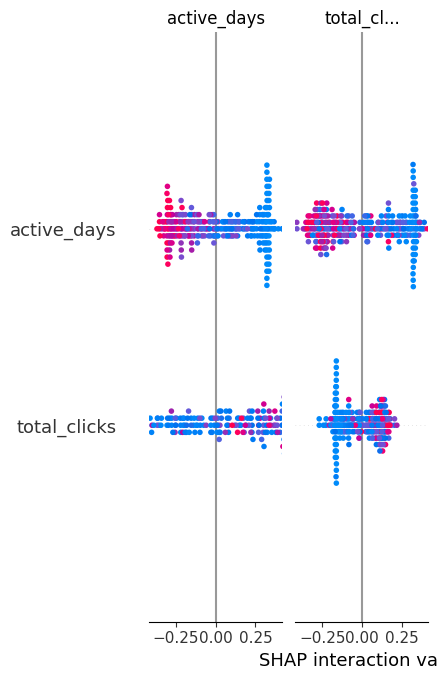

In [10]:
shap.summary_plot(shap_values.values, X_sample)

In [13]:
baseline_risk = predict_risk(student)
print("Baseline risk:", baseline_risk)

Baseline risk: 0.47


c:\Users\braxt\OneDrive\Desktop\Student Risk Personal Project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
new_risk = predict_risk(modified_student)

print("New risk:", new_risk)

New risk: 0.0047204111375316405


c:\Users\braxt\OneDrive\Desktop\Student Risk Personal Project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
print("Risk reduction:", baseline_risk - new_risk)

Risk reduction: 0.46527958886246834


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.7547169811320755
ROC-AUC: 0.8341954554201034
              precision    recall  f1-score   support

           0       0.73      0.76      0.74      3051
           1       0.78      0.75      0.76      3468

    accuracy                           0.75      6519
   macro avg       0.75      0.76      0.75      6519
weighted avg       0.76      0.75      0.75      6519



In [27]:
X.columns.tolist()

['total_clicks', 'active_days', 'studied_credits']

In [30]:
X.columns.tolist()

['total_clicks', 'active_days', 'studied_credits']

In [34]:
interventions = [
    "increase_engagement",
    "increase_consistency",
    "reduce_overload",
    "study_boost"
]

results = compare_interventions(model, X_test.iloc[0], interventions)

for r in results:
    print(r)

{'intervention': 'study_boost', 'baseline_risk': np.float64(0.05), 'new_risk': np.float64(0.01), 'reduction': np.float64(0.04)}
{'intervention': 'increase_consistency', 'baseline_risk': np.float64(0.05), 'new_risk': np.float64(0.05), 'reduction': np.float64(0.0)}
{'intervention': 'reduce_overload', 'baseline_risk': np.float64(0.05), 'new_risk': np.float64(0.05), 'reduction': np.float64(0.0)}
{'intervention': 'increase_engagement', 'baseline_risk': np.float64(0.05), 'new_risk': np.float64(0.08), 'reduction': np.float64(-0.03)}


In [43]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [48]:
student_row = 0
student = X_test.iloc[student_row]

result = student_risk_system(
    model,
    student,
    X_test,
    shap_values,
    student_row,
    interventions
)

print(result)

{'risk_score': np.float64(0.05), 'risk_level': 'LOW', 'top_risk_factors': [('active_days', np.float64(-0.05459864313083012)), ('total_clicks', np.float64(0.05459864313076868))], 'best_intervention': 'study_boost', 'expected_new_risk': np.float64(0.01), 'expected_reduction': np.float64(0.04)}


In [50]:
clean_output(result)

{'risk_score': 0.05,
 'risk_level': 'LOW',
 'top_risk_factors': [('active_days', np.float64(-0.05459864313083012)),
  ('total_clicks', np.float64(0.05459864313076868))],
 'best_intervention': 'study_boost',
 'expected_new_risk': 0.01,
 'expected_reduction': 0.04}

In [51]:
clean_result = clean_output(result)
print(clean_result)

{'risk_score': 0.05, 'risk_level': 'LOW', 'top_risk_factors': [('active_days', np.float64(-0.05459864313083012)), ('total_clicks', np.float64(0.05459864313076868))], 'best_intervention': 'study_boost', 'expected_new_risk': 0.01, 'expected_reduction': 0.04}


In [53]:
clean_result = clean_output(result)
print(clean_result)

{'risk_score': 0.05, 'risk_level': 'LOW', 'top_risk_factors': [('active_days', -0.05459864313083012), ('total_clicks', 0.05459864313076868)], 'best_intervention': 'study_boost', 'expected_new_risk': 0.01, 'expected_reduction': 0.04}
